In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(r"C:\Users\varia\OneDrive\Dragon Hoard's Index\Datasets\Cleaned Datasets\BE100 Index.xls")
data = data.set_index('datetime')

In [3]:
prev = data.shift(1)
added = data.notna() & prev.isna()
removed = data.isna() * prev.notna()

cmv = (data*added).sum(axis=1) - (prev*removed).sum(axis=1)
cmv.iloc[0] = 0.0 # set first value to 0 as cmv at t = 0 should be 0
added.head()

,375-2,497-1,10182-1,10196-1,10195-1,6071-1,10185-1,10019-1,7783-1,10212-1,...,9465-1,3182-1,79003-1,10218-1,21304-1,21306-1,92176-1,7417-1,70788-1,40391-1
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2011-02-01,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2011-03-01,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2011-04-01,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2011-05-01,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


##### choose initial index value of 1000

In [5]:
data = data.fillna(0).astype(float)
indexlevel = 1000
divisor = data.iloc[0].sum()/indexlevel
index = pd.Series(0, index = data.index, dtype = float)

for i,date in enumerate(data.index):
    mv = data.iloc[i].sum()
    divisor = divisor +  cmv.iloc[i]/indexlevel
    indexlevel = mv/divisor
    print(f'CMV Value:{cmv.iloc[i]}')
    print(f'divisor{divisor}')
    #print(f'index price{indexlevel}')
    index.iloc[i] = indexlevel

CMV Value:0.0
divisor0.45353
CMV Value:0.0
divisor0.45353
CMV Value:0.0
divisor0.45353
CMV Value:0.0
divisor0.45353
CMV Value:0.0
divisor0.45353
CMV Value:69.18
divisor0.5202516855222865
CMV Value:0.0
divisor0.5202516855222865
CMV Value:0.0
divisor0.5202516855222865
CMV Value:0.0
divisor0.5202516855222865
CMV Value:0.0
divisor0.5202516855222865
CMV Value:137.35
divisor0.6369516724676019
CMV Value:452.86
divisor0.9931286612848869
CMV Value:0.0
divisor0.9931286612848869
CMV Value:0.0
divisor0.9931286612848869
CMV Value:0.0
divisor0.9931286612848869
CMV Value:0.0
divisor0.9931286612848869
CMV Value:166.66
divisor1.1138428333106898
CMV Value:0.0
divisor1.1138428333106898
CMV Value:0.0
divisor1.1138428333106898
CMV Value:0.0
divisor1.1138428333106898
CMV Value:0.0
divisor1.1138428333106898
CMV Value:0.0
divisor1.1138428333106898
CMV Value:53.04
divisor1.14818624512941
CMV Value:534.93
divisor1.4663318961876912
CMV Value:137.35
divisor1.5437987636141688
CMV Value:0.0
divisor1.543798763614168

In [6]:
index.head()

datetime
2011-01-01    1000.000000
2011-02-01    1007.099861
2011-03-01     958.811986
2011-04-01    1025.136154
2011-05-01    1036.844310
dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

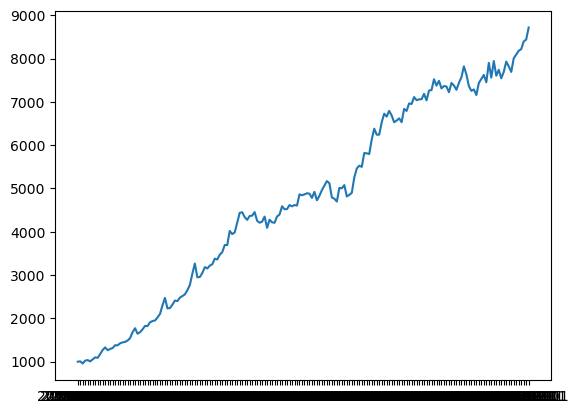

In [7]:
plt.plot(index)
plt.show

In [8]:
index.to_csv("BE100 Index Price 1000 Initial.csv")